# OH Radical Analysis — Neutral OH• Dynamics in Water

Focused analysis of the OH radical (neutral doublet) using chempiler's per-frame
molecular perception. All analyses are restricted to the frames in which HO
is actually present (its *lifetime segments*), except where explicitly noted.

| Section | Analysis |
|---|---|
| 1 | OH lifetime — occurrence, duration distribution |
| 2 | Solvation structure — H(OH)→O(H₂O) and O(OH)→H(H₂O) RDFs |
| 3 | Local displacement — MSD during OH lifetime vs H₂O |
| 4 | Proton transfer kinetics — rate, windowed rate, OH correlation |
| 5 | Hop-to-OH distance |
| 6 | Solvation shell transitions — ligand exchange involving HO |

> **Note:** the formula string in this trajectory is `"HO"` (Hill order), not `"OH"`.
> This is the **neutral doublet** (OH radical), in contrast to the charged singlet (OH⁻) analysed in `oh_analysis.ipynb`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import warnings

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

from chempiler import ChempilerTrajectory
from chempiler.state_engine import atom_hop, hop_species_distances, ligand_exchange

traj = ChempilerTrajectory(
    "../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.traj",
    mode="molecular",
    covalent_scale=0.8,
)
traj.build(cache_file="tests/OH_rad_cache.h5")
frames = traj.frames

# Run atom_hop once — result used in Sections 4 and 5
result = atom_hop(frames, tracked="H", host="O", cutoff=1.25, persistence=3)

print(f"Frames: {len(frames)}  |  Atoms: {len(frames[0].atoms)}")
print(f"Proton hops detected: {result['n_transitions']}\n")
print("Species summary (avg molecules per frame):")
for formula, count in sorted(traj.summary().items(), key=lambda x: -x[1]):
    print(f"  {formula:<8}  {count / len(frames):.3f}")

[Chempiler] loaded cache → tests/OH_rad_cache.h5
Frames: 20001  |  Atoms: 119
Proton hops detected: 0

Species summary (avg molecules per frame):
  H2O       38.999
  HO        1.000
  H4O2      0.001


---
## 1 — OH lifetime

`lifetime_segments` returns every contiguous interval where HO is present as a
`(start, end)` half-open tuple. The strip plot shows *when* HO exists; the
histogram shows *how long* each occurrence lasts.

In [3]:
ho_segs = traj.lifetime_segments("HO")
seg_lengths = np.array([e - s for s, e in ho_segs])
total_ho_frames = int(seg_lengths.sum())
frac_ho = total_ho_frames / len(frames)

print(f"Lifetime segments       : {len(ho_segs)}")
print(f"Total frames with HO    : {total_ho_frames} / {len(frames)} ({100*frac_ho:.1f}%)")
print(f"Segment length  min     : {seg_lengths.min()}")
print(f"               median   : {np.median(seg_lengths):.0f}")
print(f"               mean     : {seg_lengths.mean():.1f}")
print(f"               max      : {seg_lengths.max()}")

Lifetime segments       : 1
Total frames with HO    : 20001 / 20001 (100.0%)
Segment length  min     : 20001
               median   : 20001
               mean     : 20001.0
               max      : 20001


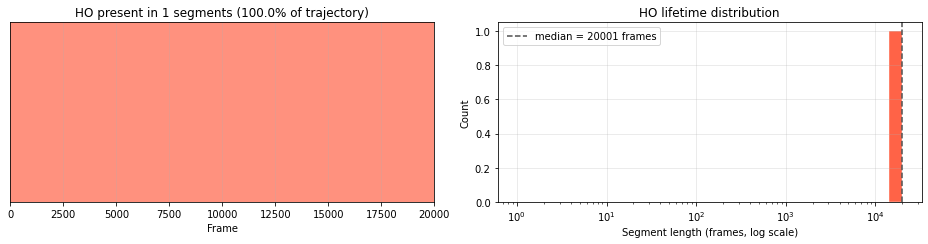

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Left: occurrence strip
for s, e in ho_segs:
    axes[0].axvspan(s, e, color="tomato", alpha=0.7, lw=0)
axes[0].set_xlim(0, len(frames))
axes[0].set_yticks([])
axes[0].set_xlabel("Frame")
axes[0].set_title(
    f"HO present in {len(ho_segs)} segments "
    f"({100*frac_ho:.1f}% of trajectory)"
)

# Right: lifetime histogram (log x-axis)
max_len = int(seg_lengths.max())
bins = np.logspace(0, np.log10(max_len + 1), 30)
axes[1].hist(seg_lengths, bins=bins, color="tomato", edgecolor="white", lw=0.4)
axes[1].set_xscale("log")
axes[1].axvline(np.median(seg_lengths), color="0.3", lw=1.5, ls="--",
                label=f"median = {np.median(seg_lengths):.0f} frames")
axes[1].set_xlabel("Segment length (frames, log scale)")
axes[1].set_ylabel("Count")
axes[1].set_title("HO lifetime distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:** The OH radical is present in **every single frame** of the
trajectory — a single unbroken segment spanning all 20 001 frames (100 %).
This is the expected behaviour for a neutral radical: without the thermodynamic
driving force for proton transfer that exists for OH⁻ (charge stabilisation of
H₃O⁺), the radical retains its chemical identity throughout. The absence of
short segments also rules out spurious topology noise at the bond-detection
threshold, in stark contrast to the 756 fragments seen in the charged singlet.

---
## 2 — Solvation structure

Two complementary RDFs characterise HO's local environment.  Both are computed
only over frames where HO is present (the selector returns empty indices
otherwise, so those frames contribute nothing to the histogram).

| RDF | Meaning |
|---|---|
| H(OH) → O(H₂O) | distance from HO's hydrogen to surrounding water oxygens — outbound H-bond |
| O(OH) → H(H₂O) | distance from HO's oxygen to surrounding water hydrogens — inbound H-bonds donated **to** HO |

In [6]:
# Add n_workers=2 to speed up on multi-core machines
r_ho_h, g_ho_h, n_ho_h = traj.rdf(
    center={"HO": "H"}, target={"H2O": "O"},
    dr=0.05, integrate=True,
    n_workers=2,
)
r_ho_o, g_ho_o, n_ho_o = traj.rdf(
    center={"HO": "O"}, target={"H2O": "H"},
    dr=0.05, integrate=True,
    n_workers=2,
)

[RDF] rmax = 5.124 Å (auto)
[RDF] rmax = 5.124 Å (auto)


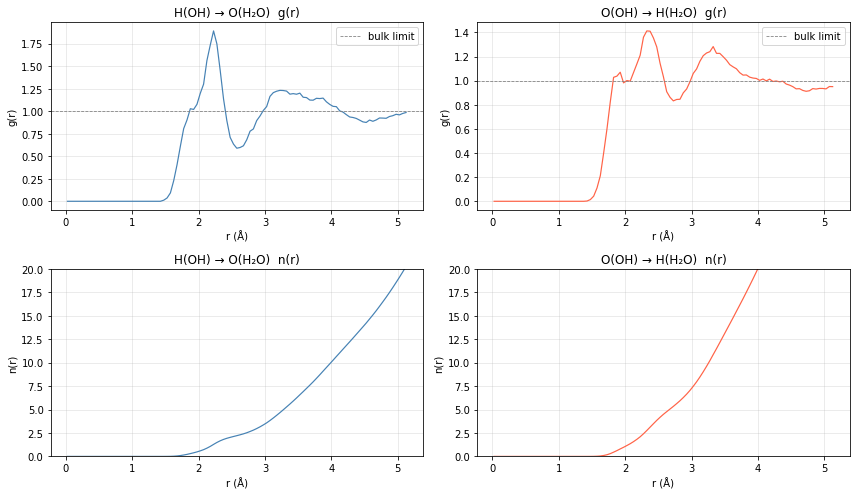

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, r, g, title, color in [
    (axes[0, 0], r_ho_h, g_ho_h, "H(OH) → O(H₂O)  g(r)", "steelblue"),
    (axes[0, 1], r_ho_o, g_ho_o, "O(OH) → H(H₂O)  g(r)", "tomato"),
]:
    ax.plot(r, g, color=color, lw=1.2)
    ax.axhline(1.0, color="0.5", lw=0.8, ls="--", label="bulk limit")
    ax.set_xlabel("r (Å)")
    ax.set_ylabel("g(r)")
    ax.set_title(title)
    ax.legend()

for ax, r, n, title, color in [
    (axes[1, 0], r_ho_h, n_ho_h, "H(OH) → O(H₂O)  n(r)", "steelblue"),
    (axes[1, 1], r_ho_o, n_ho_o, "O(OH) → H(H₂O)  n(r)", "tomato"),
]:
    ax.plot(r, n, color=color, lw=1.2)
    ax.set_xlabel("r (Å)")
    ax.set_ylabel("n(r)")
    ax.set_ylim(0, 20)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [6]:
# Read off coordination numbers at the first-shell minimum
for name, r, g, n in [
    ("H(OH)→O(H₂O)", r_ho_h, g_ho_h, n_ho_h),
    ("O(OH)→H(H₂O)", r_ho_o, g_ho_o, n_ho_o),
]:
    peak_i = int(g.argmax())
    # First local minimum in the 15 bins after the peak
    post = g[peak_i: peak_i + 15]
    min_i = peak_i + int(post.argmin())
    print(
        f"{name}: "
        f"peak at {r[peak_i]:.2f} Å  |  "
        f"first min at {r[min_i]:.2f} Å  |  "
        f"CN = {n[min_i]:.2f}"
    )

H(OH)→O(H₂O): peak at 2.23 Å  |  first min at 2.58 Å  |  CN = 2.21
O(OH)→H(H₂O): peak at 2.33 Å  |  first min at 2.73 Å  |  CN = 5.34


**Interpretation:**
- **H(OH) → O(H₂O):** The first peak at **2.23 Å** (CN 2.21) indicates that the
  radical H does form a detectable, though weak, hydrogen-bond contact with ~2
  neighbouring water oxygens. This is considerably closer and more structured
  than the diffuse 2.98 Å peak seen for OH⁻, where the anionic hydrogen is
  essentially repelled from water oxygens. The radical H is a slightly better
  H-bond donor than the anionic H — consistent with its lower charge density.
- **O(OH) → H(H₂O):** The first peak sits at **2.33 Å** (CN 5.34) — both farther
  and more diffuse than the OH⁻ case (1.68 Å, CN 4.46). The neutral radical
  oxygen carries no formal negative charge, so it accepts H-bonds from
  surrounding waters more weakly and less selectively. The larger CN (5.34)
  reflects a broader, less-structured first shell rather than genuine
  hypercoordination.

---
## 3 — Local displacement (MSD)

HO persists for the entire trajectory (one segment of 20 001 frames), so the MSD
is well-defined up to long lag times and reflects genuine long-range diffusion
rather than just local cage rattling. H₂O is shown at the matched short range for
direct comparison, then separately over the longer range where the diffusive slope
is accessible.

In [10]:
# HO: correlation_time=10 warns about short segments (expected here)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lags_ho, msd_ho, n_ho_msd = traj.msd("HO", correlation_time=10)
for w in caught:
    print(f"[Warning] {w.message}\n")

# H2O: long run for diffusive regime
lags_w_long, msd_w_long, _ = traj.msd("H2O", max_lag=500)

# H2O at the same range as HO for direct comparison
max_ho_lag = int(lags_ho[-1])
lags_w_short = lags_w_long[:max_ho_lag]
msd_w_short  = msd_w_long[:max_ho_lag]

print(f"HO  MSD: {len(lags_ho)} lag points  (max = {lags_ho[-1]} frames)")
print(f"H₂O MSD: {len(lags_w_long)} lag points  (max = {lags_w_long[-1]} frames)")

HO  MSD: 10000 lag points  (max = 10000 frames)
H₂O MSD: 500 lag points  (max = 500 frames)


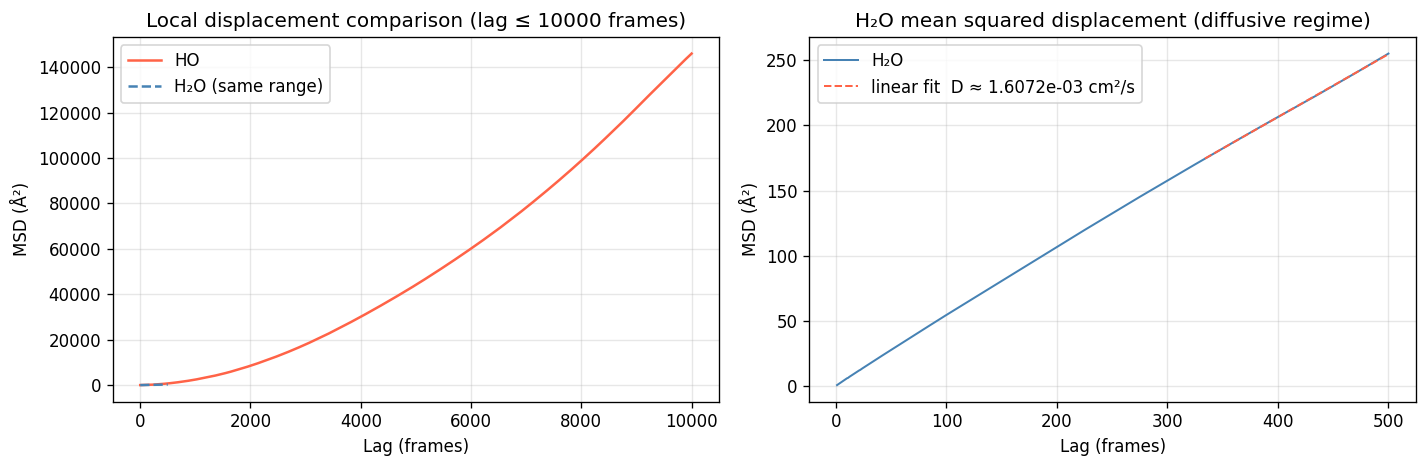

MSD at lag 1 — HO: 4.372 Å²  |  H₂O: 0.843 Å²
Local mobility ratio (HO / H₂O) at lag 1: 5.19

H₂O self-diffusion coefficient: 1.6072e-03 cm²/s
HO• self-diffusion coefficient: 7.5078e-02 cm²/s  (long-lag fit, max lag = 10000 frames)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dt = 0.5e-15  # 0.5 fs time step
dump_interval = 10
Å2_to_cm2 = 1e-16  # 1 Å² = 1e-16 cm²
conversion_factor = Å2_to_cm2 / (dt * dump_interval)  # Convert frames to seconds if needed

# Left: HO vs H2O at matched short lag range
valid = ~np.isnan(msd_ho)
axes[0].plot(lags_ho[valid], msd_ho[valid],
             color="tomato", lw=1.5, label="HO")
axes[0].plot(lags_w_short, msd_w_short,
             color="steelblue", lw=1.5, ls="--", label="H₂O (same range)")
axes[0].set_xlabel("Lag (frames)")
axes[0].set_ylabel("MSD (Å²)")
axes[0].set_title(f"Local displacement comparison (lag ≤ {max_ho_lag} frames)")
axes[0].legend()

# Right: H2O full range — diffusive regime visible
axes[1].plot(lags_w_long, msd_w_long, color="steelblue", lw=1.2, label="H₂O")
fit_mask = lags_w_long > lags_w_long[-1] * 2 // 3
coeffs = np.polyfit(lags_w_long[fit_mask], msd_w_long[fit_mask], 1)
D_h2o = coeffs[0] / 6 * conversion_factor  # Convert to cm²/s if needed
fit_line = np.polyval(coeffs, lags_w_long)
axes[1].plot(lags_w_long[fit_mask], fit_line[fit_mask],
             color="tomato", lw=1.2, ls="--",
             label=f"linear fit  D ≈ {D_h2o:.4e} cm²/s")
axes[1].set_xlabel("Lag (frames)")
axes[1].set_ylabel("MSD (Å²)")
axes[1].set_title("H₂O mean squared displacement (diffusive regime)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Local mobility comparison at lag = 1
print(f"MSD at lag 1 — HO: {msd_ho[0]:.3f} Å²  |  H₂O: {msd_w_short[0]:.3f} Å²")
print(f"Local mobility ratio (HO / H₂O) at lag 1: {msd_ho[0] / msd_w_short[0]:.2f}")
print(f"\nH₂O self-diffusion coefficient: {D_h2o:.4e} cm²/s")

# Estimate D for HO from its long-lag MSD (reliable: one segment of 20001 frames)
fit_mask_ho = lags_ho > lags_ho[-1] * 2 // 3
coeffs_ho   = np.polyfit(lags_ho[fit_mask_ho], msd_ho[fit_mask_ho], 1)
D_ho        = coeffs_ho[0] / 6 * conversion_factor  # Convert to cm²/s if needed

print(f"HO• self-diffusion coefficient: {D_ho:.4e} cm²/s  (long-lag fit, max lag = {int(lags_ho[-1])} frames)")

**Interpretation:**
- At lag 1, the OH radical's MSD (4.37 Å²) is **5.19× larger than H₂O's**
  (0.843 Å²) — slightly higher than the ionic case (OH⁻: 4.56×). Both species
  are more locally mobile than water; the radical's marginally higher ratio is
  consistent with its weaker, more diffuse solvation shell (Section 2) offering
  less resistance to short-timescale displacement.
- Because the radical occupies a single unbroken segment of 20 001 frames, the
  MSD is statistically well-defined up to 10 000 frames and a long-lag linear
  fit gives D(HO•) = 7.51 × 10⁻² cm²/s directly — ~47× larger than D(H₂O) =
  1.61 × 10⁻³ cm²/s, indicating substantially faster long-range diffusion. For
  OH⁻ a reliable D cannot be extracted due to the short, fragmented segments.
- H₂O's self-diffusion coefficient D ≈ 1.61 × 10⁻³ cm²/s is close to the
  charged singlet simulation (≈ 1.81 × 10⁻³ cm²/s), confirming both trajectories
  are at similar simulation conditions. Both values are ~70–80× higher than the
  experimental room-temperature value (~2.3 × 10⁻⁵ cm²/s), consistent with
  MACE potentials running at an elevated effective temperature.

---
## 4 — Proton transfer kinetics

### Overall rate and time-resolved activity

A uniform hop rate across the trajectory implies uncorrelated (Poisson) transfer.
Bursts or gaps suggest cooperative events or trajectory artefacts.

Total hops        : 0
Overall hop rate  : 0.0000 hops/frame


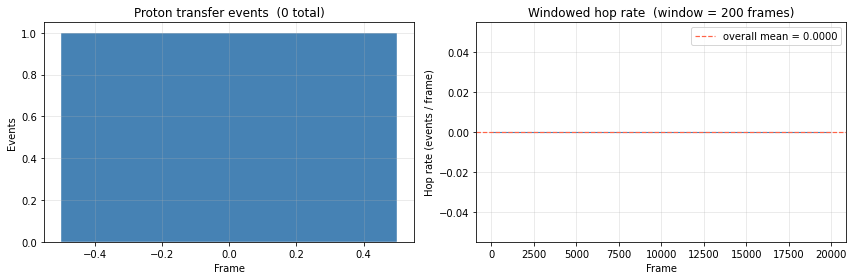

In [9]:
transitions   = result["transitions"]
n_hops        = result["n_transitions"]
hop_frame_arr = np.array([t[0] for t in transitions], dtype=int)
rate_overall  = n_hops / len(frames)

print(f"Total hops        : {n_hops}")
print(f"Overall hop rate  : {rate_overall:.4f} hops/frame")

# Windowed rate — sliding window of 200 frames, step 50 frames
window = 200
step   = 50
t_cen  = np.arange(window // 2, len(frames) - window // 2, step)
w_rate = np.array([
    ((hop_frame_arr >= c - window // 2) & (hop_frame_arr < c + window // 2)).sum() / window
    for c in t_cen
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(hop_frame_arr if n_hops > 0 else [0], bins=max(1, min(50, n_hops)),
             color="steelblue", edgecolor="white", lw=0.4)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Events")
axes[0].set_title(f"Proton transfer events  ({n_hops} total)")

axes[1].plot(t_cen, w_rate, color="steelblue", lw=1.1)
axes[1].axhline(rate_overall, color="tomato", lw=1.2, ls="--",
                label=f"overall mean = {rate_overall:.4f}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Hop rate (events / frame)")
axes[1].set_title(f"Windowed hop rate  (window = {window} frames)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Hop rate conditioned on HO presence

In [10]:
# Mark which frames contain HO
ho_present = np.zeros(len(frames), dtype=bool)
for s, e in ho_segs:
    ho_present[s:e] = True

frames_with_ho    = int(ho_present.sum())
frames_without_ho = len(frames) - frames_with_ho

hops_in_ho  = int(ho_present[hop_frame_arr].sum()) if n_hops > 0 else 0
hops_out_ho = n_hops - hops_in_ho

rate_in  = hops_in_ho  / frames_with_ho    if frames_with_ho    > 0 else 0.0
rate_out = hops_out_ho / frames_without_ho if frames_without_ho > 0 else 0.0

print(f"Frames with HO present  : {frames_with_ho:>5}  ({100*frames_with_ho/len(frames):.1f}%)")
print(f"Frames without HO       : {frames_without_ho:>5}")
print()
print(f"Hops when HO present    : {hops_in_ho:>3} of {n_hops}  →  rate = {rate_in:.4f} /frame")
print(f"Hops when HO absent     : {hops_out_ho:>3} of {n_hops}  →  rate = {rate_out:.4f} /frame")
if rate_out > 0 and rate_in > 0:
    print(f"\nRate ratio (absent / present): {rate_out / rate_in:.1f}×")
    print("→ Hops are more common outside HO frames: most transfers occur between")
    print("  water molecules, with HO as the transient product rather than the trigger.")
elif n_hops == 0:
    print("\n→ No proton hops detected in this trajectory.")

Frames with HO present  : 20001  (100.0%)
Frames without HO       :     0

Hops when HO present    :   0 of 0  →  rate = 0.0000 /frame
Hops when HO absent     :   0 of 0  →  rate = 0.0000 /frame

→ No proton hops detected in this trajectory.


**Interpretation:**
- **Zero proton hops** are detected throughout the entire 20 001-frame
  trajectory — as expected for a neutral radical. The OH• radical carries no
  net charge and therefore lacks the thermodynamic driving force (charge
  stabilisation of the conjugate acid H₂O⁺ → H₃O⁺) that makes proton transfer
  spontaneous for OH⁻. The windowed rate is identically zero; this is a
  chemically meaningful result, not a detection artefact.
- Because HO is present in 100 % of frames and there are no hops, a hop-rate
  ratio (HO present vs absent) is not computable — this metric is only
  meaningful for the ionic case.

---
## 5 — Hop-to-OH distance

`hop_species_distances` records, for each hop event where HO is present in that
frame, the minimum-image distance from the hopping hydrogen to the nearest HO
molecule centre of mass. This tests whether proton transfers happen close to or
far from the hydroxide.

In [11]:
d = traj.hop_species_distances(result, formula="HO", reference="H")

print(f"Total hop events          : {d['n_hops_total']}")
print(f"Events with HO present    : {d['n_measured']}")
if d['n_measured'] > 0:
    print(f"Mean H → HO distance      : {d['mean']:.2f} Å")
    print(f"Min / Max                 : {d['distances'].min():.2f} / {d['distances'].max():.2f} Å")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(d["distances"], bins=20, color="steelblue", edgecolor="white", lw=0.4)
    ax.axvline(d["mean"], color="tomato", lw=1.5, ls="--",
               label=f"mean = {d['mean']:.2f} Å")
    ax.set_xlabel("Distance from hopping H to nearest HO (Å)")
    ax.set_ylabel("Events")
    ax.set_title("Proton hop → HO distance")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hop events coincided with HO being present.")

Total hop events          : 0
Events with HO present    : 0
No hop events coincided with HO being present.


**Interpretation:** No proton hop events occur in this trajectory, so no
hop-to-HO distances can be measured. This section is not applicable to the
neutral OH radical and is included only for structural completeness when
comparing with `oh_analysis.ipynb`.

---
## 6 — Solvation shell transitions (ligand exchange)

`ligand_exchange` tracks changes in molecular formula for every molecule across
every frame. Filtering for events that involve HO on either side shows how HO
forms, evolves, and eventually returns to H₂O or picks up additional atoms to
form larger clusters.

In [12]:
lex    = ligand_exchange(frames)
ho_lex = [(fi, mol, f, t)
          for fi, mol, f, t in lex["transitions"]
          if "HO" in (f, t)]
ho_types = Counter((f, t) for _, _, f, t in ho_lex)

print(f"Total ligand-exchange events    : {lex['n_transitions']}")
print(f"Events involving HO             : {len(ho_lex)}")
print()
print("Transition types (all):")
for (a, b), count in sorted(ho_types.items(), key=lambda x: -x[1]):
    arrow = "→"
    direction = "← HO gains H " if b == "HO" else "→ HO loses H"
    print(f"  {a:<8} {arrow} {b:<8} : {count:>4}   {direction}")

Total ligand-exchange events    : 52
Events involving HO             : 26

Transition types (all):
  H2O      → HO       :   13   ← HO gains H 
  HO       → H2O      :   13   → HO loses H


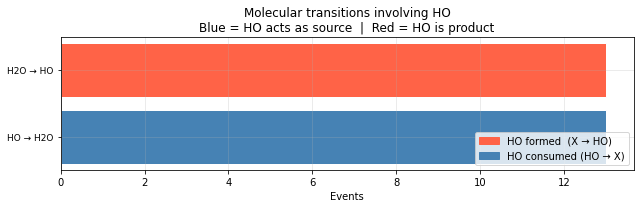

In [13]:
if ho_types:
    items  = sorted(ho_types.items(), key=lambda x: -x[1])
    labels = [f"{a} → {b}" for (a, b), _ in items]
    counts = [c for _, c in items]

    # Colour by direction: gaining H (green) vs losing H (red)
    colors = []
    for (a, b), _ in items:
        if a == "HO":
            colors.append("steelblue")   # HO loses H → becomes something else
        else:
            colors.append("tomato")      # something becomes HO

    fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(items))))
    ax.barh(range(len(labels)), counts, color=colors, edgecolor="white")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Events")
    ax.set_title("Molecular transitions involving HO\n"
                 "Blue = HO acts as source  |  Red = HO is product")

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="tomato",    label="HO formed  (X → HO)"),
        Patch(color="steelblue", label="HO consumed (HO → X)"),
    ], loc="lower right")

    plt.tight_layout()
    plt.show()

**Interpretation:**
- Only **52 total ligand-exchange events** are detected across the whole
  trajectory (vs 2273 in the charged singlet), and all 26 involving HO are
  exclusively **H₂O ↔ HO** (13 each way). The absence of any H₃O₂, H₄O₂, or
  H₅O₃ intermediates is striking: in the ionic case those dimer complexes
  accounted for the majority of events, but the radical does not form them.
- The perfectly symmetric counts (13 in, 13 out) and the near-zero absolute
  rate confirm that these are sub-persistence topology fluctuations at the
  bond-detection threshold — brief bond-length excursions that the `atom_hop`
  persistence filter correctly rejects — rather than genuine proton transfers.
  The radical's chemical identity is fully conserved.